# Weekly update: pT-weighted runs and the Chang-recipe pilots

Two pieces of work, each rebuilt from saved data every time this notebook runs: the
pT-weighting study (verified, with the caveat its VERIFY.md requires) and the Chang-recipe
(Sun et al.) regime-B pilots that Delta is anchored on (telemetry: the pilots are still being
read out). *Held-out* (ROC-test) is the dataset's separate archive that neither training nor
checkpoint selection ever sees; *validation* is an internal split of the training data.

Rerun from the repository root:
`.venv-hgq2/bin/python -m nbconvert --to notebook --execute --inplace messages/2026-09-29-results-notebook/weekly_update.ipynb`

In [1]:
import time
T0 = time.time()
from IPython.display import Image, Markdown, display
import numpy as np
import nbhelpers as H

H.apply_style()
H.FIG_DIR = H.HERE / "figures_weekly"   # keep the full summary's figures untouched


def md(text):
    display(Markdown(text))


def show(png, caption):
    display(Image(filename=str(png), width=960))
    md(caption)


md(f"Executed {time.strftime('%Y-%m-%d %H:%M %Z')}. Figures are also saved as PNG and SVG in "
   f"`{H.FIG_DIR.relative_to(H.REPO)}/`.")

Executed 2026-09-29 11:57 PDT. Figures are also saved as PNG and SVG in `messages/2026-09-29-results-notebook/figures_weekly/`.

## Part 1. pT-weighted runs

Three arms of the same binary-weight tagger (Round-14 N = 8 W1A8 configuration, no EBOP
target), eight seeds each: no sample weights, jet-pT weights capped at 5, and jet-pT weights
without a cap. Every number below is recomputed from the saved held-out prediction arrays and
matches the campaign's VERIFY.md.

**Caveat, in plain words.** The arms, seeds and weight settings were fixed before the runs
started. The headline metric, the seed-by-seed comparison, the pass/fail criterion and the
pT-bin analysis were chosen after the results were in. The VERIFY.md therefore confirms that
these are the numbers the saved arrays give; it does not certify a pre-registered test.

In [2]:
ptw = H.load_ptw()
A = H.PTW_ARMS
plain = {"BASE": "unweighted baseline", "PTW5": "weights, cap 5", "PTWNC": "weights, no cap"}
ns, n = len(ptw["seeds"]), ptw["n"]
head = ["seed"]
for a in A:
    head += [f"{plain[a]}: AUC", f"{plain[a]}: accuracy"]
rows = []
for s in ptw["seeds"]:
    r = [f"s{s}"]
    for a in A:
        r += [f"{ptw['per'][(a, s)]['auc']:.4f}", H.pct(ptw["per"][(a, s)]["acc"])]
    rows.append(r)
r = [f"**mean ± sd ({ns} seeds)**"]
for a in A:
    auc, acc = ptw["arr"][a]["auc"], ptw["arr"][a]["acc"]
    r += [f"**{auc.mean():.4f} ± {auc.std(ddof=1):.4f}**", f"**{H.pct(acc.mean())} ± {100 * acc.std(ddof=1):.2f}**"]
rows.append(r)
r = ["**gap vs unweighted, paired 95 % t-interval (seeds lower)**"]
for a in A:
    if a == "BASE":
        r += ["reference", "reference"]
        continue
    g, h = ptw["gaps"][(a, "auc")], ptw["gaps"][(a, "acc")]
    r += [f"{g['mean']:+.4f} [{g['lo']:+.4f}, {g['hi']:+.4f}] ({g['lower']}/{g['n']})",
          f"{100 * h['mean']:+.2f} pp [{100 * h['lo']:+.2f}, {100 * h['hi']:+.2f}] ({h['lower']}/{h['n']})"]
rows.append(r)
md(f"**Held-out (ROC-test) split, n = {n:,} jets per seed; macro one-vs-rest AUC and top-1 accuracy; {ns} seeds per "
   "arm. Status: verified (recomputed here from the saved arrays; matches VERIFY.md).**")
md(H.md_table(head, rows))
n_match = sum(abs(ptw["per"][(a, s)]["auc"] - ptw["claim"][a][s - 1]) < 1e-9 for a in A for s in ptw["seeds"])
md(f"Check: {n_match} of {len(A) * ns} per-seed AUCs agree with the stored `{H.PTW}/summary.json` to 1e-9.")

**Held-out (ROC-test) split, n = 260,000 jets per seed; macro one-vs-rest AUC and top-1 accuracy; 8 seeds per arm. Status: verified (recomputed here from the saved arrays; matches VERIFY.md).**

| seed | unweighted baseline: AUC | unweighted baseline: accuracy | weights, cap 5: AUC | weights, cap 5: accuracy | weights, no cap: AUC | weights, no cap: accuracy |
|---|---|---|---|---|---|---|
| s1 | 0.8718 | 62.42 % | 0.8591 | 60.86 % | 0.8583 | 60.61 % |
| s2 | 0.8714 | 62.29 % | 0.8592 | 60.61 % | 0.8586 | 60.35 % |
| s3 | 0.8713 | 62.29 % | 0.8641 | 61.33 % | 0.8605 | 61.21 % |
| s4 | 0.8682 | 61.96 % | 0.8587 | 60.27 % | 0.8597 | 60.44 % |
| s5 | 0.8713 | 62.50 % | 0.8591 | 60.69 % | 0.8544 | 60.04 % |
| s6 | 0.8729 | 62.60 % | 0.8615 | 60.77 % | 0.8575 | 60.20 % |
| s7 | 0.8709 | 62.33 % | 0.8612 | 61.31 % | 0.8608 | 60.85 % |
| s8 | 0.8712 | 62.33 % | 0.8593 | 60.56 % | 0.8594 | 60.32 % |
| **mean ± sd (8 seeds)** | **0.8711 ± 0.0013** | **62.34 % ± 0.19** | **0.8603 ± 0.0019** | **60.80 % ± 0.37** | **0.8587 ± 0.0020** | **60.50 % ± 0.38** |
| **gap vs unweighted, paired 95 % t-interval (seeds lower)** | reference | reference | -0.0108 [-0.0124, -0.0093] (8/8) | -1.54 pp [-1.83, -1.25] (8/8) | -0.0125 [-0.0148, -0.0101] (8/8) | -1.84 pp [-2.23, -1.45] (8/8) |

Check: 24 of 24 per-seed AUCs agree with the stored `bnjettag/roc-results/ptw-n8/summary.json` to 1e-9.

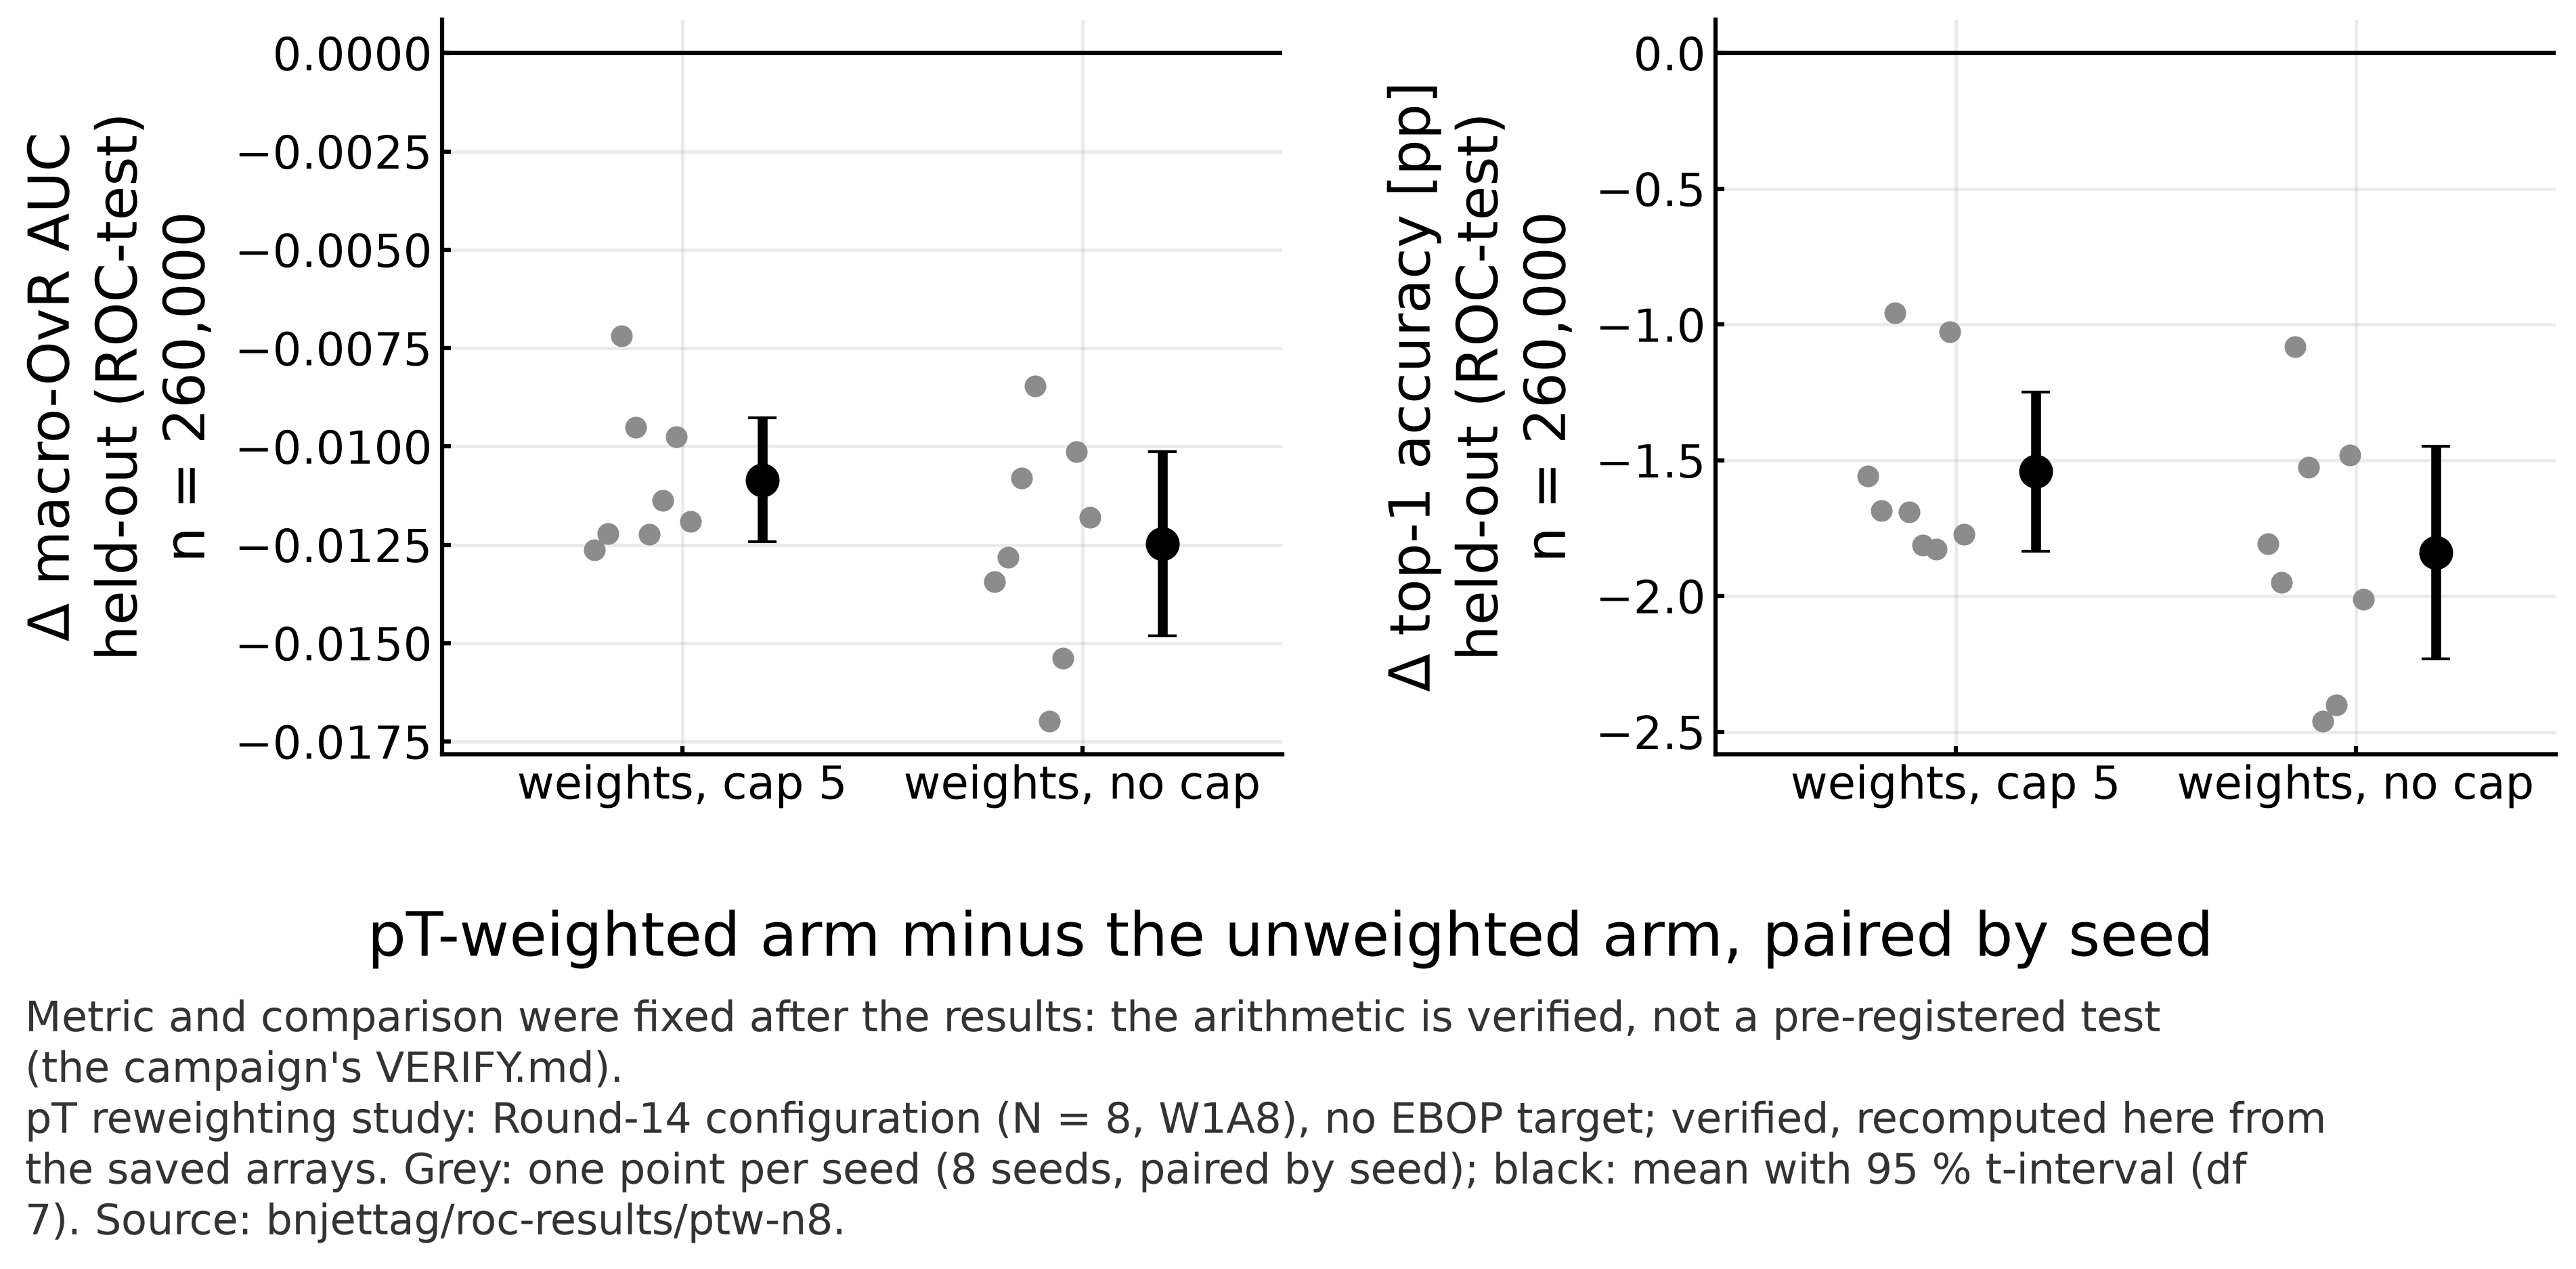

**Figure 1.** Paired differences to the unweighted arm on each of 8 seeds (grey) and their mean with a 95 % t-interval (black), held-out (ROC-test) split, n = 260,000. Both weighted arms are lower on 8/8 and 8/8 seeds in macro-OvR AUC. Verified; the metric and comparison were fixed after the results, so this is not a pre-registered test.

In [3]:
png = H.fig_ptw_gaps(ptw, name="weekly1_ptw_paired_gaps")
g5, gN = ptw["gaps"][("PTW5", "auc")], ptw["gaps"][("PTWNC", "auc")]
show(png, f"**Figure 1.** Paired differences to the unweighted arm on each of {ns} seeds (grey) and their mean with a "
          f"95 % t-interval (black), held-out (ROC-test) split, n = {n:,}. Both weighted arms are lower on "
          f"{g5['lower']}/{ns} and {gN['lower']}/{ns} seeds in macro-OvR AUC. Verified; the metric and comparison were "
          "fixed after the results, so this is not a pre-registered test.")

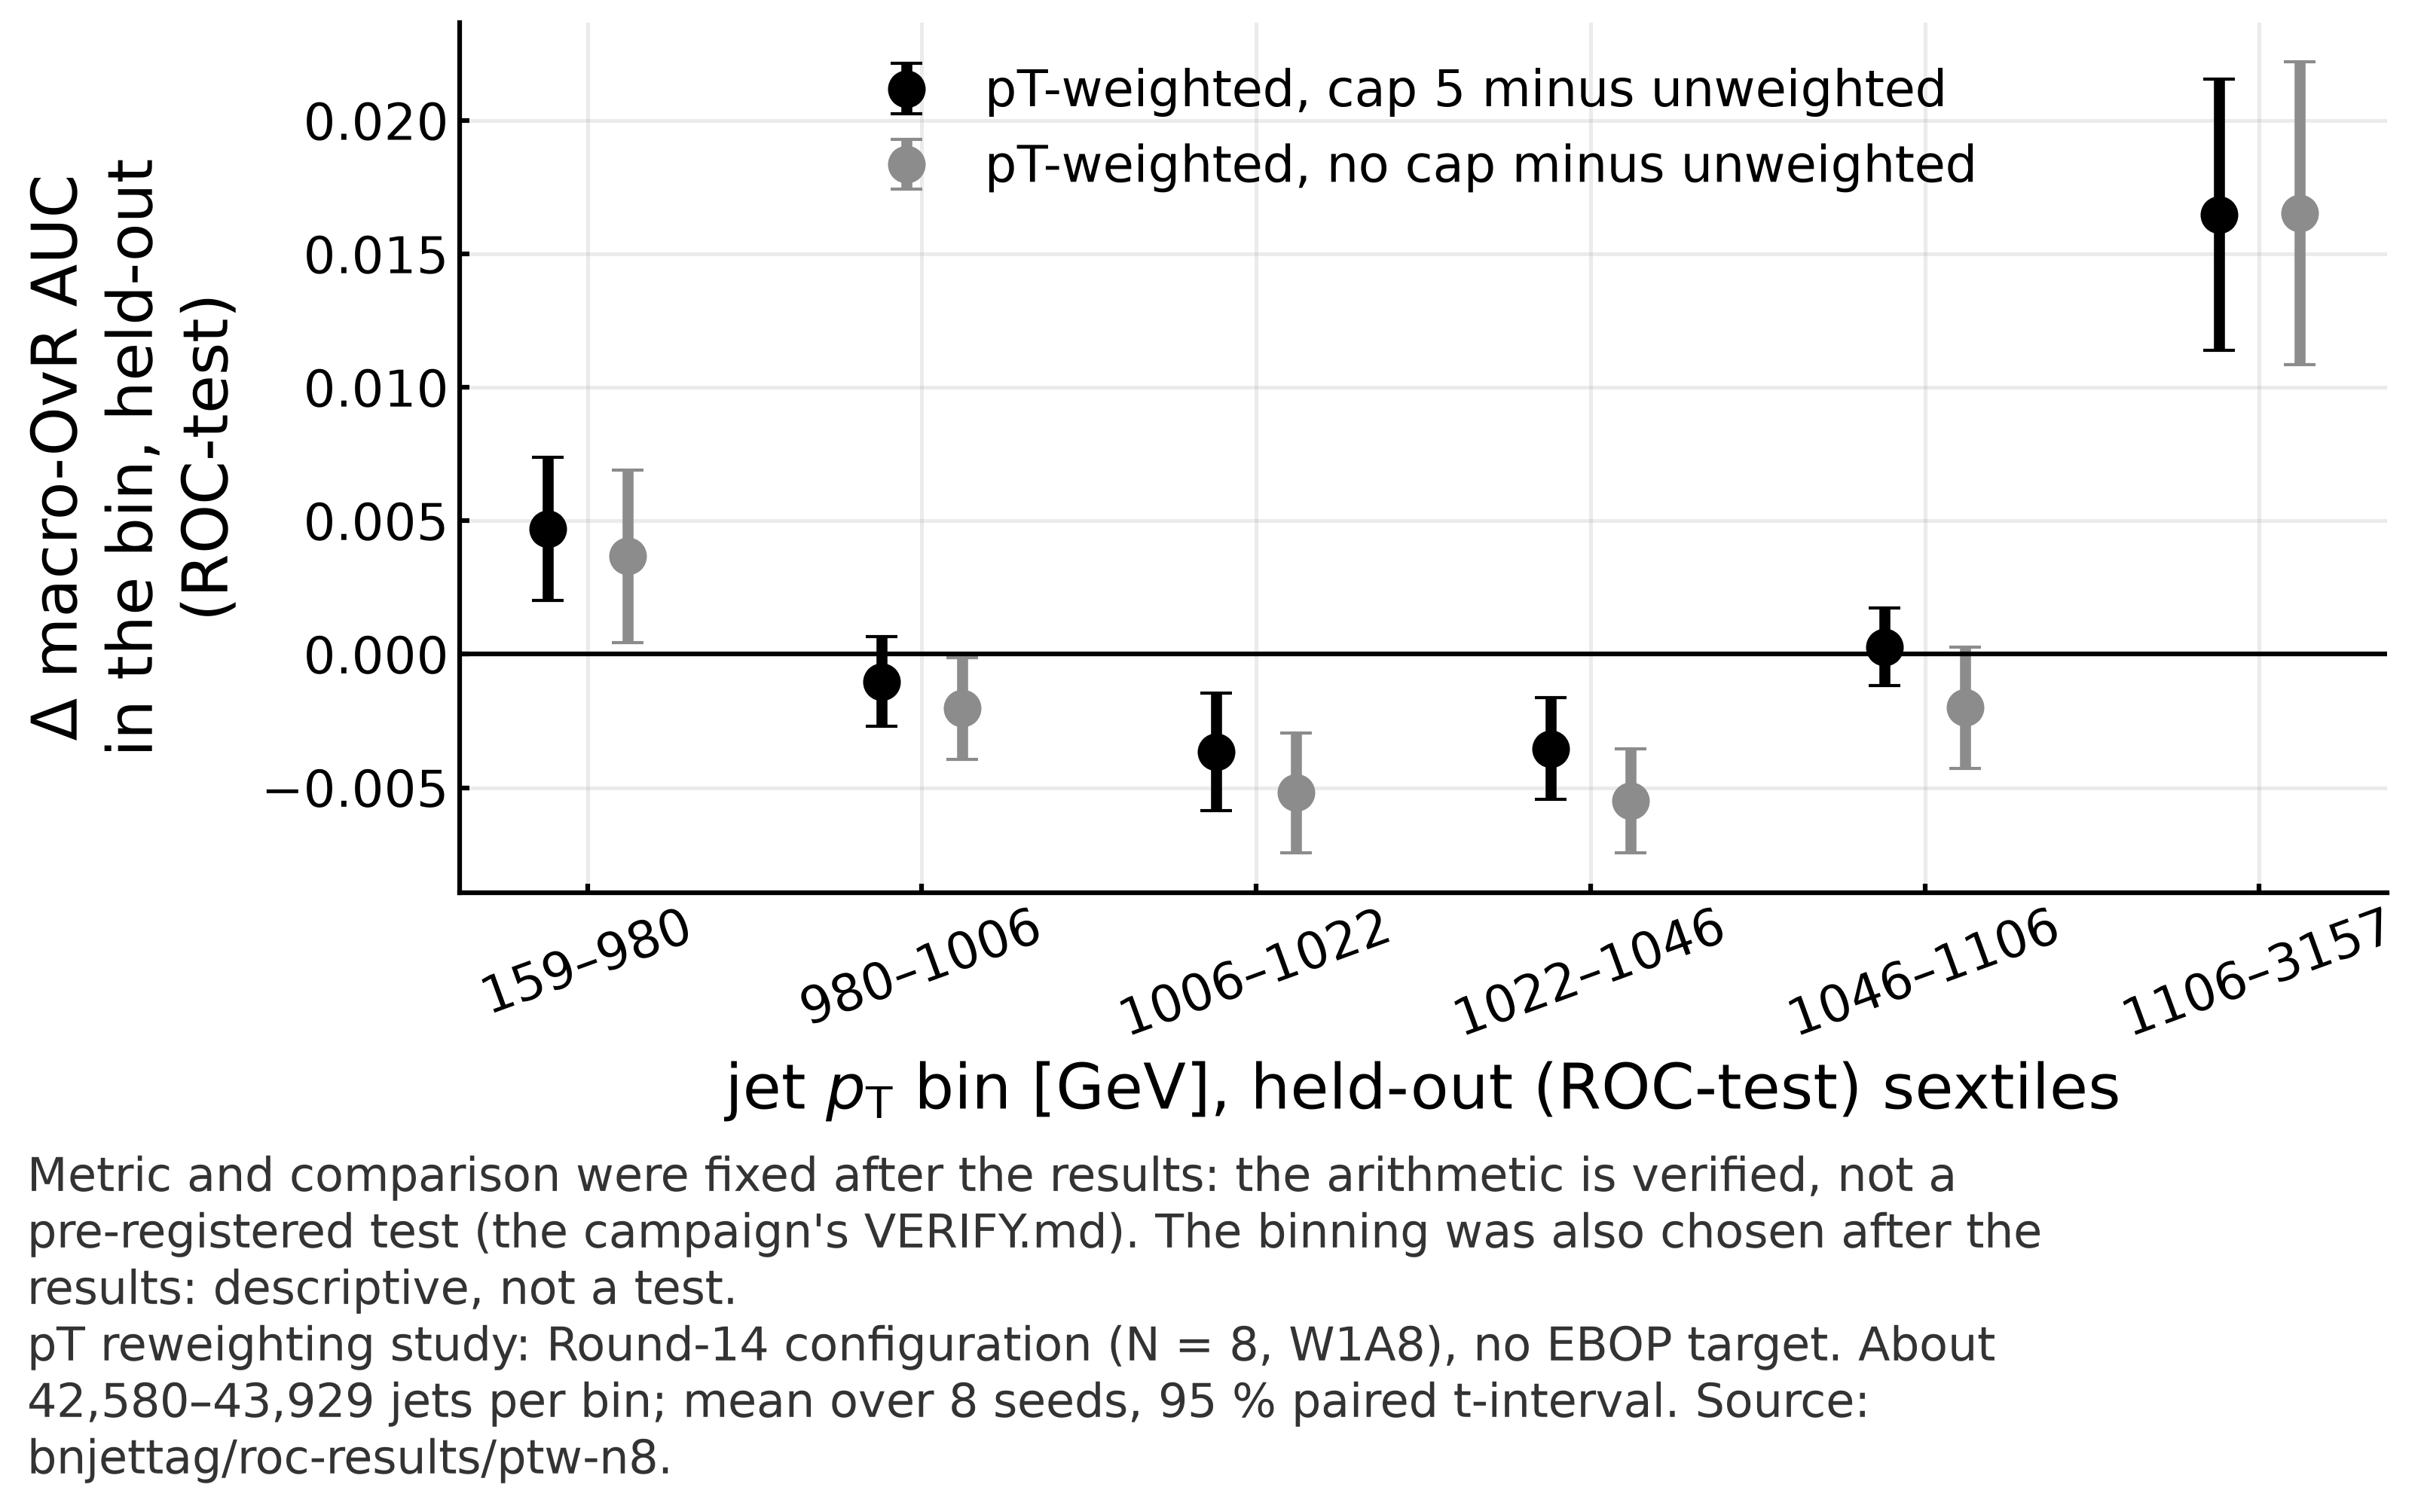

**Figure 2.** Held-out (ROC-test) macro-OvR AUC difference to the unweighted arm inside each jet-pT sextile (GeV), mean over 8 seeds with a 95 % paired t-interval. For weights with cap 5 the interval lies above zero in 159–980, 1106–3157 GeV and below zero in 1006–1022, 1022–1046 GeV. The bins were chosen after the results: descriptive, not a test.

In [4]:
def bins_where(arm, sign):
    out = [f"{ptw['lo'][i]:.0f}–{ptw['hi'][i]:.0f}" for i, t in enumerate(ptw["bin_gaps"][arm])
           if (sign > 0 and t["lo"] > 0) or (sign < 0 and t["hi"] < 0)]
    return ", ".join(out) or "none"


png = H.fig_ptw_bins(ptw, name="weekly2_ptw_pt_bins")
show(png, f"**Figure 2.** Held-out (ROC-test) macro-OvR AUC difference to the unweighted arm inside each jet-pT sextile "
          f"(GeV), mean over {ns} seeds with a 95 % paired t-interval. For weights with cap 5 the interval lies above "
          f"zero in {bins_where('PTW5', +1)} GeV and below zero in {bins_where('PTW5', -1)} GeV. The bins were chosen "
          "after the results: descriptive, not a test.")

In [5]:
d = H.t_interval(ptw["arr"]["PTW5"]["auc"] - ptw["arr"]["PTWNC"]["auc"])
ends = (ptw["bin_gaps"]["PTW5"][0]["lo"] > 0 and ptw["bin_gaps"]["PTW5"][-1]["lo"] > 0
        and any(t["hi"] < 0 for t in ptw["bin_gaps"]["PTW5"][1:-1]))
md(f"**Takeaway, in the VERIFY.md's terms.** The question \"does pT reweighting improve held-out macro AUC?\" is "
   f"falsified for both arms (cap 5 {g5['mean']:+.4f} [{g5['lo']:+.4f}, {g5['hi']:+.4f}], no cap {gN['mean']:+.4f} "
   f"[{gN['lo']:+.4f}, {gN['hi']:+.4f}], lower on {g5['lower']}/{ns} and {gN['lower']}/{ns} seeds); the cap-5 versus "
   f"no-cap difference, {d['mean']:+.4f} [{d['lo']:+.4f}, {d['hi']:+.4f}], is not resolvable at {ns} seeds"
   + ("; by jet pT the weighting gains at both ends of the range and loses in the centre." if ends else "."))

**Takeaway, in the VERIFY.md's terms.** The question "does pT reweighting improve held-out macro AUC?" is falsified for both arms (cap 5 -0.0108 [-0.0124, -0.0093], no cap -0.0125 [-0.0148, -0.0101], lower on 8/8 and 8/8 seeds); the cap-5 versus no-cap difference, +0.0016 [-0.0002, +0.0034], is not resolvable at 8 seeds; by jet pT the weighting gains at both ends of the range and loses in the centre.

## Part 2. Chang-recipe (Sun et al.) regime-B pilots

Binary-weight N = 64 taggers trained on the Sun et al. schedule toward an EBOPs target, one
seed per arm, in two pods on the NRP cluster. Each arm pauses at epoch 500 for a pre-registered
readout. Delta's wave-2 design is anchored on these pilots.

**Status of everything in this part: pilot telemetry, validation split, not a result; the
pre-registered epoch-500 rules are being evaluated.** The K=3 pod's readout has run; the K=5
pod's readout waits until its last arm (C′-s1) pauses.

In [6]:
STATUS = "Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated"
ch = H.load_chang()
rb = H.load_readout_b3()
cert = {r["name"]: r for r in rb["cert"]["runs"]}
ent = {r["name"]: r for r in rb["ent"]["runs"]}
ORDER = [("a", "1"), ("a", "2"), ("d", "1"), ("e1", "1"), ("cprime", "1"), ("a07-350", "1"), ("c", "1"), ("f", "1")]
arms = sorted(ch["arms"], key=lambda a: ORDER.index((a["arm"], a["seed"])) if (a["arm"], a["seed"]) in ORDER else 99)
PENDING = "pending (readout after C′-s1 pauses)"


def run_name(a):
    return f"chang0926-{a['arm']}-n{a['n_part']}-s{a['seed']}"


def cert_cell(a):
    r = cert.get(run_name(a))
    if r is None:
        return PENDING
    if not r["checkpoints"]:
        return r["status"]
    c = r["checkpoints"][0]
    ok = all(k["status"] == "CERTIFIED" for k in r["checkpoints"])
    return (f"{'CERTIFIED' if ok else 'NOT certified'} ({len(r['checkpoints'])} files): retraced "
            f"{c['retraced_ebops']:,} = logged {c['logged_ebops']:,}")


def attn_cell(a):
    r = ent.get(run_name(a))
    if r is None:
        return PENDING
    z = next(iter(r["zero_bit"].values()))
    e = next(iter(r["entropy"].values()))
    return (f"0-bit Q/K/V {z['Q']['zero_bit_fraction']:.2f}/{z['K']['zero_bit_fraction']:.2f}/"
            f"{z['V']['zero_bit_fraction']:.2f}; entropy per head "
            + ", ".join(f"{h['entropy_over_log_n']:.2f}" for h in e["heads"]))


tab = []
for a in arms:
    tr = ~np.isnan(a["traced"])
    j = np.where(tr)[0][-1]
    v = a["verified"] or {}
    state = (f"paused at epoch {v['completed_epochs']:,} (checkpoint verified in pod)" if v.get("completed_epochs")
             else f"running: epoch {int(a['epoch'].max())} at the {a['copy_stamp'][9:]}Z log copy")
    tab.append([f"{a['label']} ({a['pod']})", H.CHANG_PLAIN.get(a["arm"], a["arm"]), f"{a['target']:,.0f}",
                f"{a['traced'][j]:,.0f} (epoch {int(a['epoch'][j])})",
                f"feasible {int(a['feasible'][j])}, degenerate {int(a['degenerate'][j])}",
                f"{a['val_auc'][-1]:.4f} / {H.pct(a['val_acc'][-1])} (epoch {int(a['epoch'].max())})",
                state, cert_cell(a), attn_cell(a)])
md(f"**{STATUS}.** One row per arm, newest saved per-arm log. Validation = the pilots' internal split, "
   f"n = {ch['n_val']:,}. {H.CHANG_KEY}")
md(H.md_table(["arm (pod)", "model", "EBOPs target", "latest traced EBOPs (epoch)", "flags at that trace",
               f"validation AUC / accuracy, n = {ch['n_val']:,} (epoch)", "state",
               "EBOPs certification (readout)", "attention state (readout)"], tab))

**Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated.** One row per arm, newest saved per-arm log. Validation = the pilots' internal split, n = 62,000. E: the small binary model (Chang-sized); A07: the wider binary model with learned positions. Every arm runs the Sun et al. schedule; arm codes as in the training-batch STUDY.md.

| arm (pod) | model | EBOPs target | latest traced EBOPs (epoch) | flags at that trace | validation AUC / accuracy, n = 62,000 (epoch) | state | EBOPs certification (readout) | attention state (readout) |
|---|---|---|---|---|---|---|---|---|
| A-s1 (K=5 pod) | E model | 350,000 | 315,700 (epoch 500) | feasible 0, degenerate 1 | 0.4992 / 20.19 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | pending (readout after C′-s1 pauses) | pending (readout after C′-s1 pauses) |
| A-s2 (K=5 pod) | E model | 350,000 | 336,841 (epoch 500) | feasible 1, degenerate 0 | 0.6451 / 31.21 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | pending (readout after C′-s1 pauses) | pending (readout after C′-s1 pauses) |
| D-s1 (K=5 pod) | E model, our optimizer | 350,000 | 563,100 (epoch 500) | feasible 0, degenerate 0 | 0.6663 / 31.58 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | pending (readout after C′-s1 pauses) | pending (readout after C′-s1 pauses) |
| E1-s1 (K=5 pod) | E model, one head | 350,000 | 375,397 (epoch 500) | feasible 0, degenerate 0 | 0.6250 / 30.53 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | pending (readout after C′-s1 pauses) | pending (readout after C′-s1 pauses) |
| C′-s1 (K=5 pod) | A07 model, old quantizer | 5,000,000 | 5,341,210 (epoch 330) | feasible 0, degenerate 0 | 0.8540 / 55.48 % (epoch 339) | running: epoch 339 at the 1854Z log copy | pending (readout after C′-s1 pauses) | pending (readout after C′-s1 pauses) |
| A07-350-s1 (K=3 pod) | A07 model | 350,000 | 381,965 (epoch 500) | feasible 0, degenerate 0 | 0.5000 / 20.26 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | no feasible checkpoint | 0-bit Q/K/V 1.00/1.00/1.00; entropy per head 1.00, 1.00, 1.00, 1.00 |
| C-s1 (K=3 pod) | A07 model | 5,000,000 | 4,592,840 (epoch 500) | feasible 1, degenerate 0 | 0.8088 / 48.59 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | CERTIFIED (2 files): retraced 4,880,224 = logged 4,880,224 | 0-bit Q/K/V 0.00/0.00/0.09; entropy per head 0.62, 0.91, 0.54, 0.88 |
| F-s1 (K=3 pod) | E model + learned positions | 350,000 | 433,344 (epoch 500) | feasible 0, degenerate 0 | 0.6246 / 27.95 % (epoch 500) | paused at epoch 500 (checkpoint verified in pod) | CERTIFIED (2 files): retraced 325,319 = logged 325,319 | 0-bit Q/K/V 1.00/1.00/1.00; entropy per head 1.00, 1.00 |

In [7]:
rows = []
for r in rb["cert"]["runs"]:
    if not r["checkpoints"]:
        rows.append([r["arm"] + f"-s{r['seed']}", "none", r["status"], "–", "–", "–", "–", "–", "–"])
    for c in r["checkpoints"]:
        rows.append([r["arm"] + f"-s{r['seed']}", c["which"].replace("snapshot500_", ""), c["status"],
                     f"{c['logged_ebops']:,}", f"{c['retraced_ebops']:,}", f"{c['stored_ebops']:,}",
                     f"{c['target_ebops']:,.0f}", f"{c['zero_floor_ebops']:,}", c["epoch"]])
md(f"**Readout of the K=3 pod, EBOPs certification** (`{H.READOUT_B3}/certify-snapshot-0500.json`). {STATUS}. "
   "Each stored epoch-500 checkpoint is traced again over the full training split and its EBOPs compared with the "
   "logged value; CERTIFIED means retraced = logged within the file's tolerance. The certified checkpoint is the "
   "arm's stored best feasible one, selected at the epoch shown, not the last epoch.")
md(H.md_table(["arm", "checkpoint file", "status", "logged EBOPs", "retraced EBOPs", "stored EBOPs", "target",
               "0-bit floor", "selected epoch (as recorded)"], rows))
rows = []
for r in rb["ent"]["runs"]:
    z = next(iter(r["zero_bit"].values()))
    e = next(iter(r["entropy"].values()))
    rows.append([r["arm"] + "-s1" if r["name"].endswith("-s1") else r["arm"], r["checkpoint_reason"],
                 ", ".join(f"{h['entropy_over_log_n']:.3f}" for h in e["heads"]),
                 ", ".join(f"{h['per_jet_std']:.3f}" for h in e["heads"]),
                 f"{z['Q']['zero_bit_fraction']:.2f} / {z['K']['zero_bit_fraction']:.2f} / {z['V']['zero_bit_fraction']:.2f}",
                 ", ".join(str(x) for x in z["QK_live_pairs_per_head"])])
e0 = rb["ent"]
md(f"**Readout of the K=3 pod, attention state at epoch {e0['epoch']}** (`{H.READOUT_B3}/a26-entropy-epoch-0500.json`; "
   f"{e0['split']} split, test set used: {'yes' if e0['test_set_used'] else 'no'}). {STATUS}. Entropy is the file's "
   f"definition: {e0['definition']}. An entropy of 1.000 is uniform attention over the {next(iter(e0['runs'][0]['entropy'].values()))['n_keys']} "
   "constituents; a per-jet sd of 0 means it does not change from jet to jet. A 0-bit fraction of 1.00 means every "
   "channel of Q, K or V carries no bits.")
md(H.md_table(["arm", "checkpoint read", "entropy per head (/log n)", "per-jet sd per head", "0-bit fraction Q / K / V",
               "Q·K live channel pairs per head"], rows))

**Readout of the K=3 pod, EBOPs certification** (`campaigns/2026-09-26-training-batch/readout/b3/readout-epoch-0500-42abed-b3/certify-snapshot-0500.json`). Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated. Each stored epoch-500 checkpoint is traced again over the full training split and its EBOPs compared with the logged value; CERTIFIED means retraced = logged within the file's tolerance. The certified checkpoint is the arm's stored best feasible one, selected at the epoch shown, not the last epoch.

| arm | checkpoint file | status | logged EBOPs | retraced EBOPs | stored EBOPs | target | 0-bit floor | selected epoch (as recorded) |
|---|---|---|---|---|---|---|---|---|
| C-s1 | primary | CERTIFIED | 4,880,224 | 4,880,224 | 4,880,224 | 5,000,000 | 343,053 | 19 |
| C-s1 | auc_sensitivity | CERTIFIED | 4,880,224 | 4,880,224 | 4,880,224 | 5,000,000 | 343,053 | 19 |
| F-s1 | primary | CERTIFIED | 325,319 | 325,319 | 325,319 | 350,000 | 171,526 | 289 |
| F-s1 | auc_sensitivity | CERTIFIED | 325,319 | 325,319 | 325,319 | 350,000 | 171,526 | 289 |
| A07-350-s1 | none | no feasible checkpoint | – | – | – | – | – | – |

**Readout of the K=3 pod, attention state at epoch 500** (`campaigns/2026-09-26-training-batch/readout/b3/readout-epoch-0500-42abed-b3/a26-entropy-epoch-0500.json`; validation split, test set used: no). Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated. Entropy is the file's definition: mean over jets and query rows of -sum p log p / log 64, p = softmax output / row sum; unrenormalized value and row sums beside it. An entropy of 1.000 is uniform attention over the 64 constituents; a per-jet sd of 0 means it does not change from jet to jet. A 0-bit fraction of 1.00 means every channel of Q, K or V carries no bits.

| arm | checkpoint read | entropy per head (/log n) | per-jet sd per head | 0-bit fraction Q / K / V | Q·K live channel pairs per head |
|---|---|---|---|---|---|
| A07-350-s1 | no feasible checkpoint as of epoch: lowest-EBOPs file | 1.000, 1.000, 1.000, 1.000 | 0.000, 0.000, 0.000, 0.000 | 1.00 / 1.00 / 1.00 | 0, 0, 0, 0 |
| C-s1 | best_feasible present (feasible as of epoch) | 0.622, 0.914, 0.544, 0.880 | 0.182, 0.083, 0.171, 0.138 | 0.00 / 0.00 / 0.09 | 8, 8, 8, 8 |
| F-s1 | best_feasible present (feasible as of epoch) | 1.000, 1.000 | 0.000, 0.000 | 1.00 / 1.00 / 1.00 | 0, 0 |

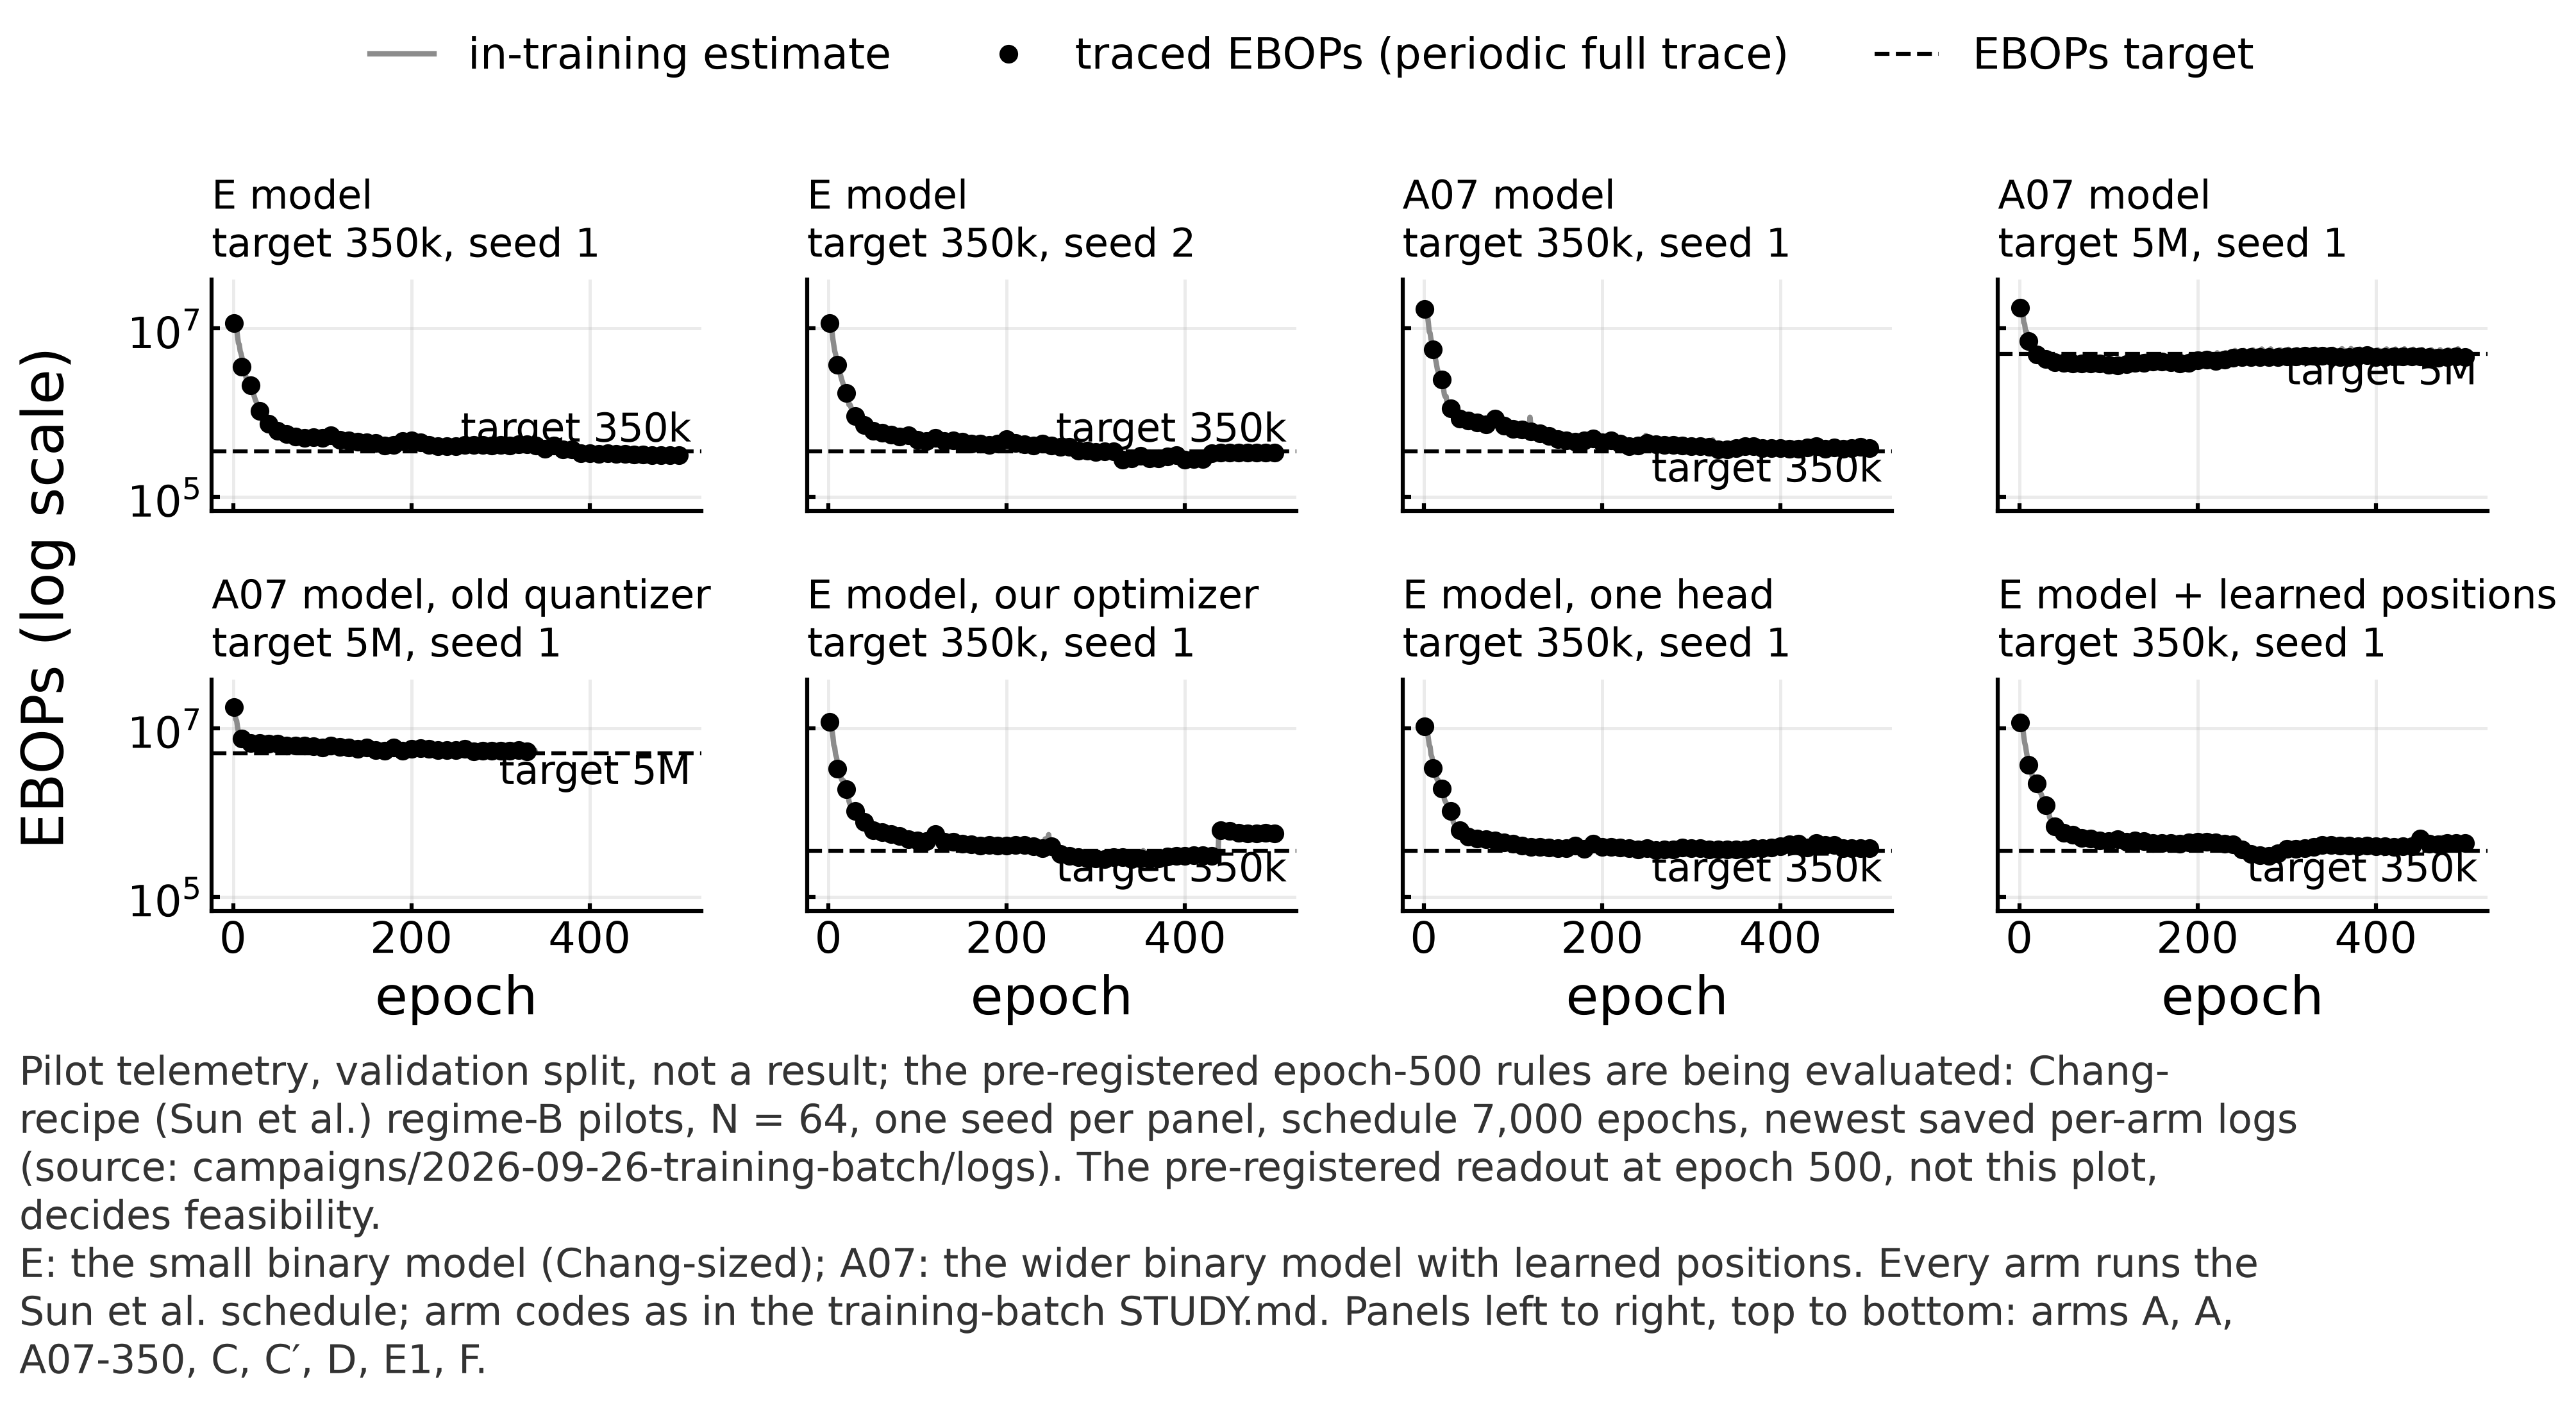

**Figure 3.** Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated. Traced EBOPs (black points) and the in-training estimate (grey) per arm against its target (dashed), log scale, from the newest saved per-arm logs. Paused at epoch 500: A-s1, A-s2, D-s1, E1-s1, A07-350-s1, C-s1, F-s1; still running: C′-s1.

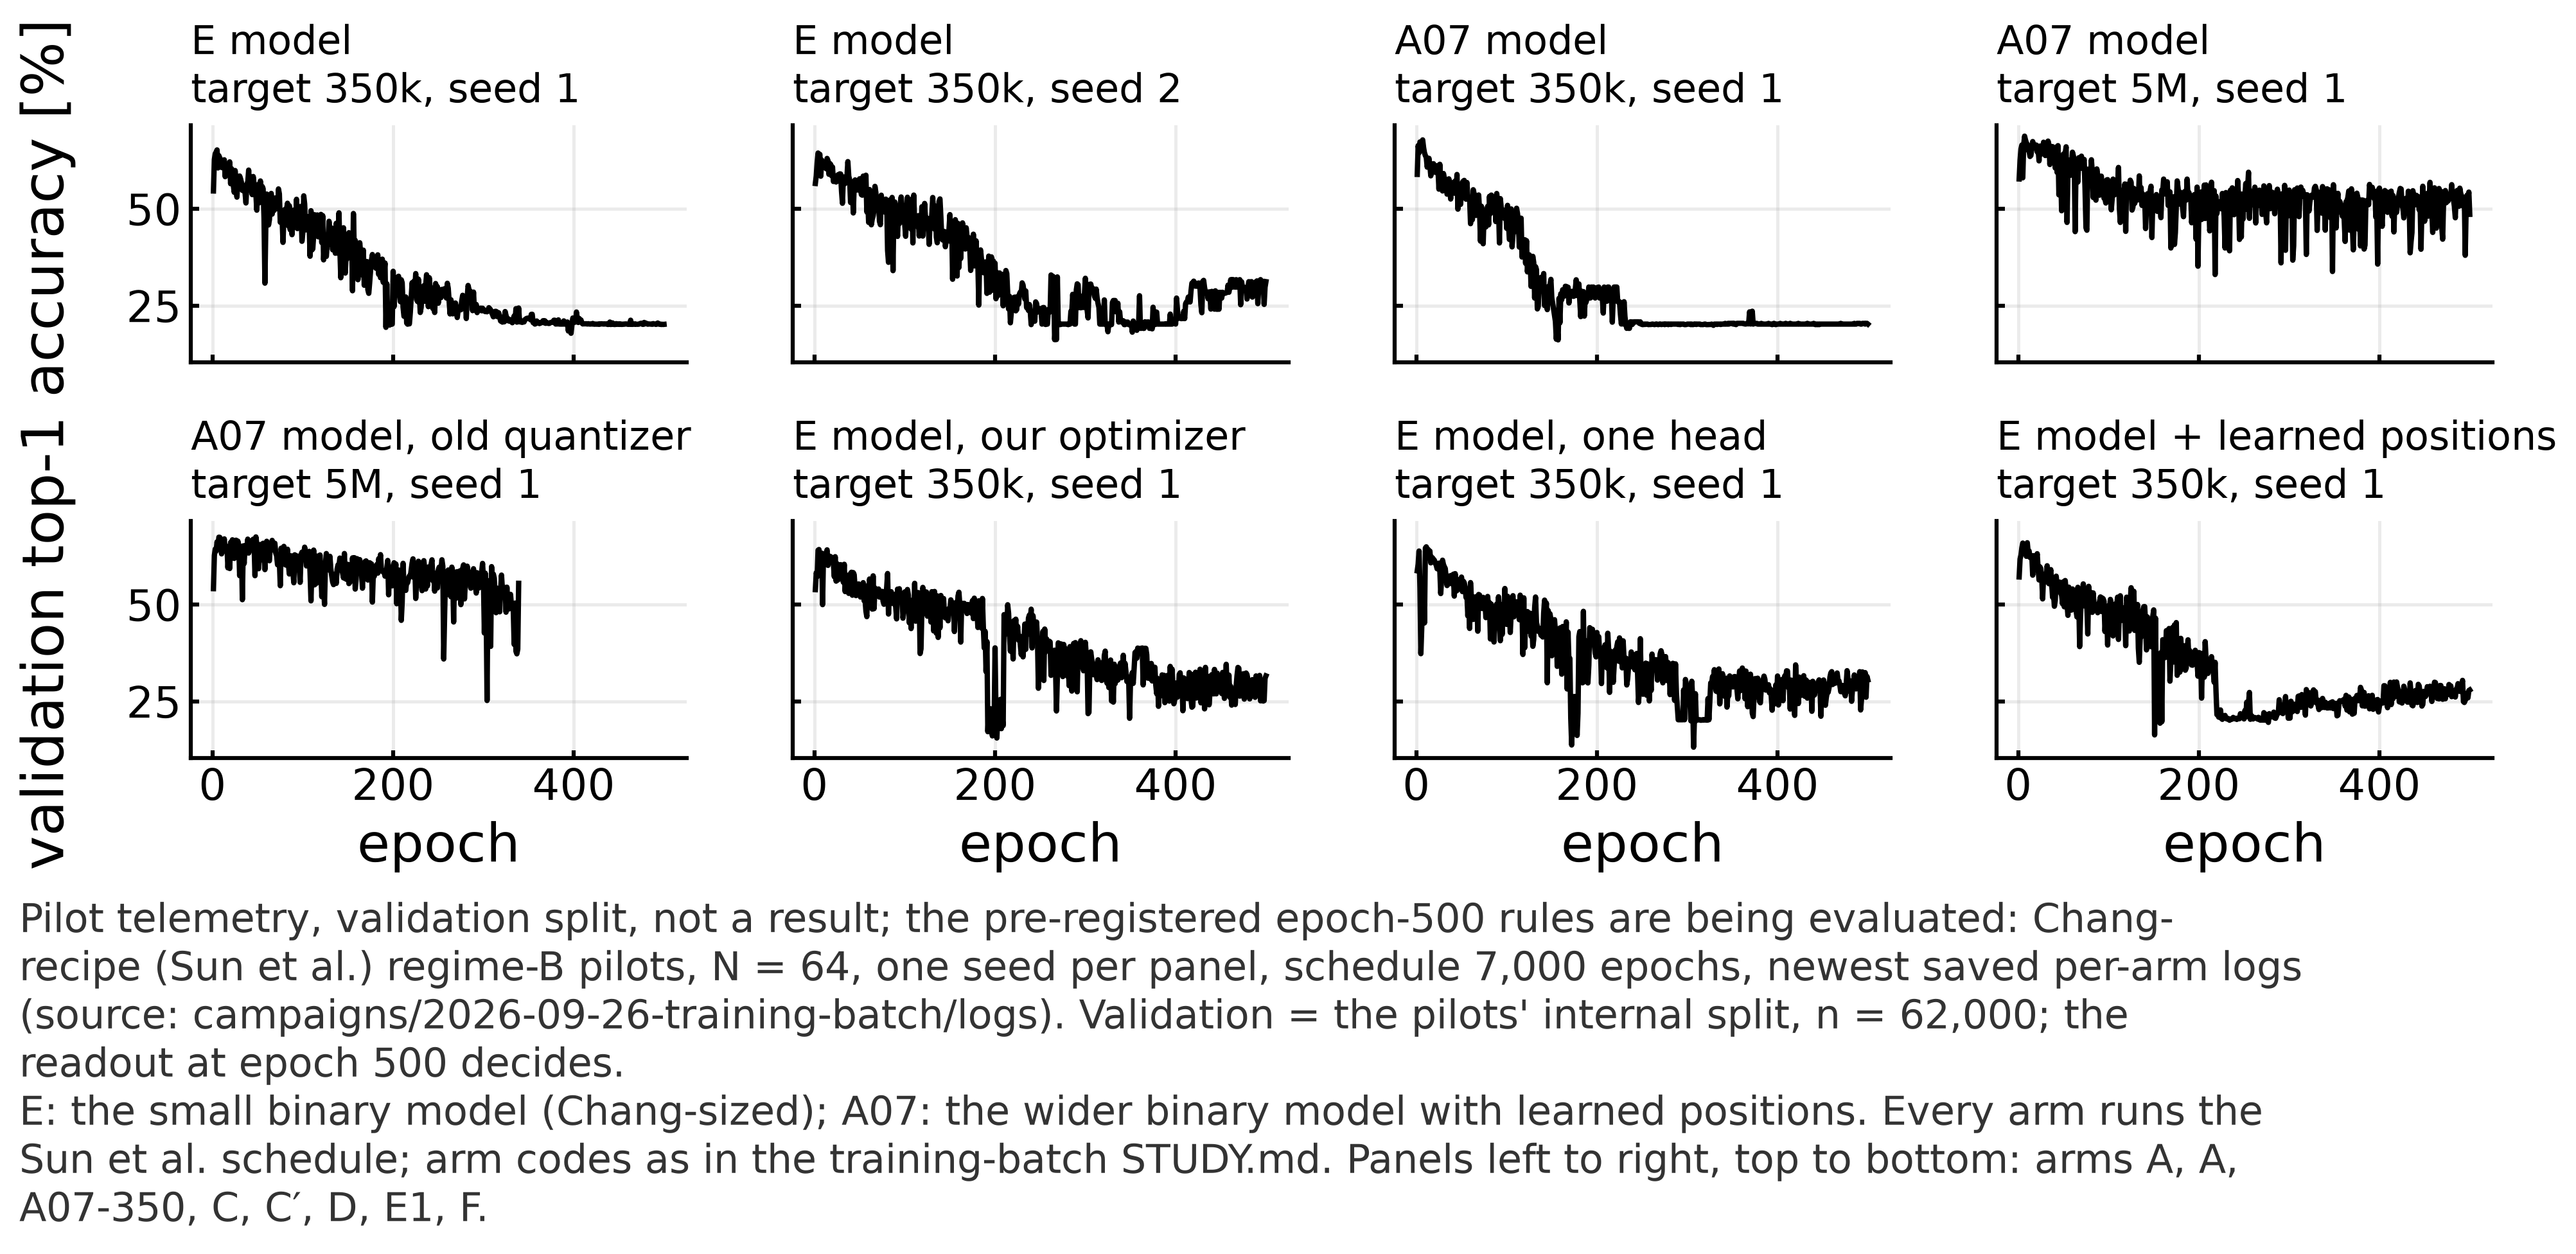

**Figure 4.** Pilot telemetry, validation split, not a result; the pre-registered epoch-500 rules are being evaluated. Validation top-1 accuracy (n = 62,000) per epoch for the same arms. The pre-registered readout, not these curves, decides which checkpoint counts.

In [8]:
png = H.fig_chang(ch, "ebops", status=STATUS, name="weekly3_chang_pilot_ebops")
paused = [a["label"] for a in arms if (a["verified"] or {}).get("completed_epochs")]
running = [a["label"] for a in arms if not (a["verified"] or {}).get("completed_epochs")]
show(png, f"**Figure 3.** {STATUS}. Traced EBOPs (black points) and the in-training estimate (grey) per arm against "
          f"its target (dashed), log scale, from the newest saved per-arm logs. Paused at epoch 500: "
          f"{', '.join(paused) or 'none'}; still running: {', '.join(running) or 'none'}.")
png = H.fig_chang(ch, "valacc", status=STATUS, name="weekly4_chang_pilot_valacc")
show(png, f"**Figure 4.** {STATUS}. Validation top-1 accuracy (n = {ch['n_val']:,}) per epoch for the same arms. "
          "The pre-registered readout, not these curves, decides which checkpoint counts.")

## Other work this week (not shown)

The full summary in this folder (`results_summary.ipynb`) covers the rest: the EBOP-constrained
N = 8 ablation, the archived Round-14 accuracy and FPGA synthesis, the GPU benchmark
(`campaigns/2026-09-29-gpu-benchmark/`) and the Delta memory canary
(`campaigns/2026-09-27-delta-screen/`).

In [9]:
md("**Files read by this run** (size, modification time):\n\n" + H.sources_table())
md(f"Notebook runtime: {time.time() - T0:.0f} s.")

**Files read by this run** (size, modification time):

| file read by this run | bytes | modified (local time) |
|---|---|---|
| `bnjettag/roc-results/ptw-n8/BASE-s1.npz` | 5,890,833 | 2026-09-26 13:16 |
| `bnjettag/roc-results/ptw-n8/BASE-s2.npz` | 5,889,754 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/BASE-s3.npz` | 5,889,863 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/BASE-s4.npz` | 5,878,191 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/BASE-s5.npz` | 5,888,248 | 2026-09-26 13:20 |
| `bnjettag/roc-results/ptw-n8/BASE-s6.npz` | 5,887,479 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/BASE-s7.npz` | 5,887,881 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/BASE-s8.npz` | 5,896,981 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTW5-s1.npz` | 5,896,805 | 2026-09-26 13:16 |
| `bnjettag/roc-results/ptw-n8/PTW5-s2.npz` | 5,892,098 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/PTW5-s3.npz` | 5,886,905 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/PTW5-s4.npz` | 5,848,762 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/PTW5-s5.npz` | 5,869,939 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/PTW5-s6.npz` | 5,884,052 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/PTW5-s7.npz` | 5,880,938 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTW5-s8.npz` | 5,892,727 | 2026-09-26 13:24 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s1.npz` | 5,886,888 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s2.npz` | 5,895,925 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s3.npz` | 5,892,825 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s4.npz` | 5,875,899 | 2026-09-26 13:20 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s5.npz` | 5,864,494 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s6.npz` | 5,878,521 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s7.npz` | 5,879,943 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s8.npz` | 5,891,607 | 2026-09-26 13:24 |
| `bnjettag/roc-results/ptw-n8/summary.json` | 107,999 | 2026-09-26 13:25 |
| `campaigns/2026-09-26-training-batch/STUDY.md` | 258,726 | 2026-09-28 20:28 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1854Z.log` | 121,644 | 2026-09-29 11:54 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a-n64-s2-kai-chang0926-pilotb5-42abed-0-20260929T1854Z.log` | 121,517 | 2026-09-29 11:54 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a07-350-n64-s1-kai-chang0926-pilotb3-42abed-0-final-20260929T1613Z.log` | 122,681 | 2026-09-29 09:13 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-c-n64-s1-kai-chang0926-pilotb3-42abed-0-final-20260929T1613Z.log` | 123,578 | 2026-09-29 09:13 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-cprime-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1854Z.log` | 81,793 | 2026-09-29 11:54 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-d-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1854Z.log` | 121,569 | 2026-09-29 11:54 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-e1-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1854Z.log` | 121,126 | 2026-09-29 11:54 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-f-n64-s1-kai-chang0926-pilotb3-42abed-0-final-20260929T1613Z.log` | 129,341 | 2026-09-29 09:13 |
| `campaigns/2026-09-26-training-batch/readout/b3/readout-epoch-0500-42abed-b3/a26-entropy-epoch-0500.json` | 10,851 | 2026-09-29 10:59 |
| `campaigns/2026-09-26-training-batch/readout/b3/readout-epoch-0500-42abed-b3/certify-snapshot-0500.json` | 3,627 | 2026-09-29 10:50 |

Notebook runtime: 10 s.